In [2]:
# ━━━━━━━━━━━━ CONFIGURACIÓN INICIAL ━━━━━━━━━━━━
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose

import seaborn as sns
sns.set_style("darkgrid")  # aplica el estilo global

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import  Dense, LSTM, Input, Reshape
from tensorflow.keras.callbacks import EarlyStopping

from pathlib import Path

In [3]:
# ━━━━━━━━━━━━ MONTAR GOOGLE DRIVE ━━━━━━━━━━━━
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ━━━━━━━━━━━━ CARGA DE ARCHIVO ━━━━━━━━━━━━
file_path = "/content/drive/MyDrive/ProyectoIntegrador/ModeloPronosticos/data/consolidado_exportacionestotalcategoria.csv"
df = pd.read_csv(file_path)

In [5]:
base = Path("/content/drive/MyDrive/ModeloPronosticos/data")

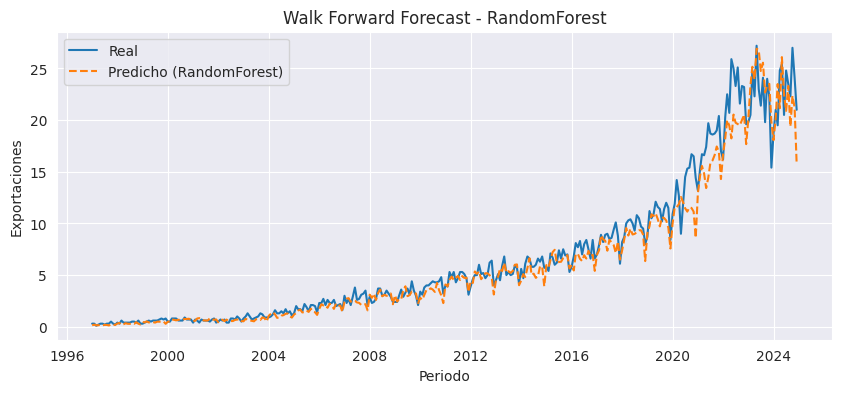

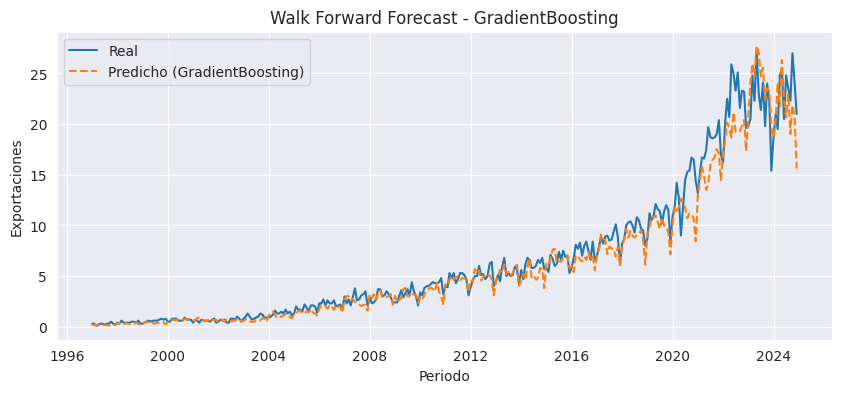

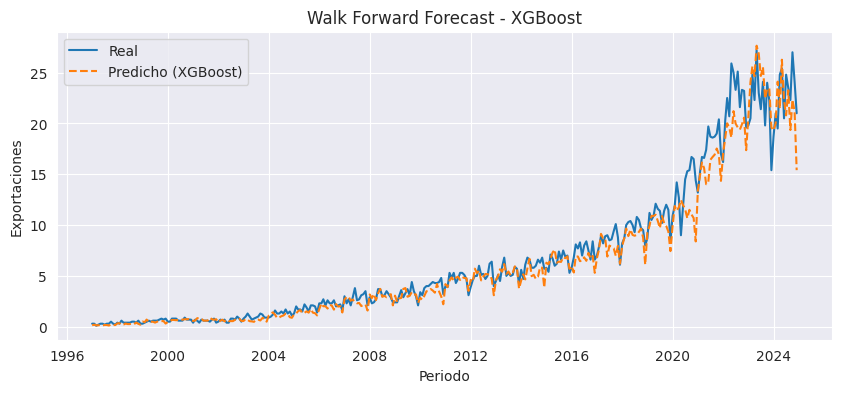

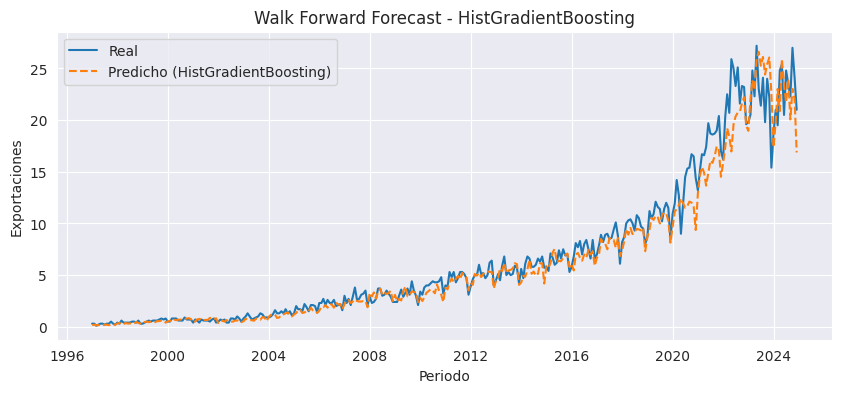

In [6]:
df = pd.read_csv(file_path)
#---
df = df[df["SubCategoria"] == "Tequila 100%"].reset_index(drop=True)
df["Periodo"] = pd.to_datetime(df["Year"].astype(str) + "-" +
                               df["Mes"].astype(str).str.zfill(2))
df = (
    df
    .sort_values("Periodo")
    .reset_index(drop=True)
    .set_index("Periodo", drop=True)
)

window = 12
lag_period = 12
train_size = window + lag_period

modelos = {
    "RandomForest": RandomForestRegressor(random_state=0),
    "GradientBoosting": GradientBoostingRegressor(random_state=0),
    "XGBoost": XGBRegressor(random_state=0, verbosity=0),
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=0)
}

metricas = {n: [] for n in modelos}
preds    = {n: [] for n in modelos}

n = len(df)
for start in range(0, n - train_size - window + 1, window):
    train_val = df["Valor"].iloc[start : start + train_size]
    test_val  = df["Valor"].iloc[start + train_size : start + train_size + window]
    idx_test  = test_val.index

    if train_val.empty or test_val.empty:
        continue

    seasonal_idx = train_val.groupby(train_val.index.month).mean() - train_val.mean()
    trend_train  = train_val.rolling(window=lag_period, min_periods=1).mean()

    resid_train = train_val - trend_train - train_val.index.month.map(seasonal_idx)

    df_tr = pd.DataFrame({"Residuo": resid_train}).dropna()
    if df_tr.empty:
        continue

    df_tr["Mes"]        = df_tr.index.month
    df_tr["Año"]        = df_tr.index.year
    df_tr["Mes_seno"]   = np.sin(2*np.pi*df_tr["Mes"]/12)
    df_tr["Mes_coseno"] = np.cos(2*np.pi*df_tr["Mes"]/12)
    df_tr["Lag1"]       = df_tr["Residuo"].shift(1)
    df_tr["Lag12"]      = df_tr["Residuo"].shift(lag_period)
    df_tr = df_tr.dropna()
    if df_tr.empty:
        continue

    X_tr = df_tr[["Mes","Año","Mes_seno","Mes_coseno","Lag1","Lag12"]]
    y_tr = df_tr["Residuo"]

    last_resid = resid_train.dropna()
    lag1_val  = last_resid.iloc[-1]
    lag12_val = last_resid.iloc[-lag_period]

    df_te = pd.DataFrame(index=idx_test)
    df_te["Mes"]        = df_te.index.month
    df_te["Año"]        = df_te.index.year
    df_te["Mes_seno"]   = np.sin(2*np.pi*df_te["Mes"]/12)
    df_te["Mes_coseno"] = np.cos(2*np.pi*df_te["Mes"]/12)
    df_te["Lag1"]       = lag1_val
    df_te["Lag12"]      = lag12_val

    X_te = df_te[["Mes","Año","Mes_seno","Mes_coseno","Lag1","Lag12"]]
    real = test_val.values

    trend_pred    = np.repeat(trend_train.iloc[-1], window)
    seasonal_pred = df_te["Mes"].map(seasonal_idx).values

    for nombre, model in modelos.items():
        model.fit(X_tr, y_tr)
        resid_pred = model.predict(X_te)
        y_pred     = trend_pred + seasonal_pred + resid_pred

        metricas[nombre].append({
            "Inicio_test": idx_test.min(),
            "MAE":  mean_absolute_error(real, y_pred),
            "RMSE": np.sqrt(mean_squared_error(real, y_pred)),
            "R2":   r2_score(real, y_pred)
        })

        preds[nombre].append(pd.DataFrame({
            "Periodo":  idx_test,
            "Real":     real,
            "Predicho": y_pred
        }))

out = base / "resultados"
out.mkdir(parents=True, exist_ok=True)

for nombre in modelos:
    if not preds[nombre]:
        print(f"Omitiendo {nombre}: sin predicciones.")
        continue

    df_m = pd.DataFrame(metricas[nombre])
    df_p = pd.concat(preds[nombre], ignore_index=True)
    df_m.to_csv(out / f"metricas_{nombre}.csv",    index=False)
    df_p.to_csv(out / f"predicciones_{nombre}.csv",index=False)

    plt.figure(figsize=(10,4))
    plt.plot(df_p["Periodo"], df_p["Real"],     label="Real")
    plt.plot(df_p["Periodo"], df_p["Predicho"], linestyle="--", label=f"Predicho ({nombre})")
    plt.title(f"Walk Forward Forecast - {nombre}")
    plt.xlabel("Periodo")
    plt.ylabel("Exportaciones")
    plt.legend()
    plt.grid(True)
    plt.show()

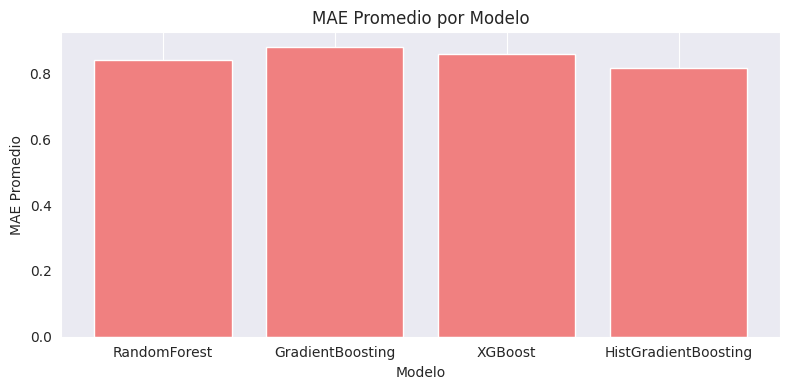

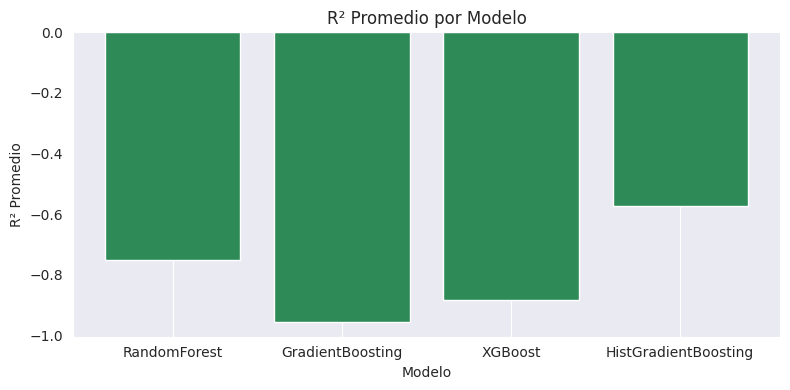

In [7]:

# Ruta de salida
base = Path("/content/drive/MyDrive/ModeloPronosticos/data")
out = base / "resultados"

# Modelos considerados
modelos = ["RandomForest", "GradientBoosting", "XGBoost", "HistGradientBoosting"]

# Cargar métricas
maes, r2s = [], []
for nombre in modelos:
    file = out / f"metricas_{nombre}.csv"
    try:
        df = pd.read_csv(file)
        maes.append(df["MAE"].mean())
        r2s.append(df["R2"].mean())
    except FileNotFoundError:
        maes.append(None)
        r2s.append(None)
        print(f"[Advertencia] No se encontró: {file.name}")

# Crear DataFrame resumen
df_eval = pd.DataFrame({
    "Modelo": modelos,
    "MAE_Promedio": maes,
    "R2_Promedio": r2s
}).dropna()

# Gráfico MAE
plt.figure(figsize=(8, 4))
plt.bar(df_eval["Modelo"], df_eval["MAE_Promedio"], color="lightcoral")
plt.title("MAE Promedio por Modelo")
plt.xlabel("Modelo")
plt.ylabel("MAE Promedio")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(out / "grafico_mae_promedio.png")
plt.show()

# Gráfico R²
plt.figure(figsize=(8, 4))
plt.bar(df_eval["Modelo"], df_eval["R2_Promedio"], color="seagreen")
plt.title("R² Promedio por Modelo")
plt.xlabel("Modelo")
plt.ylabel("R² Promedio")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(out / "grafico_r2_promedio.png")
plt.show()



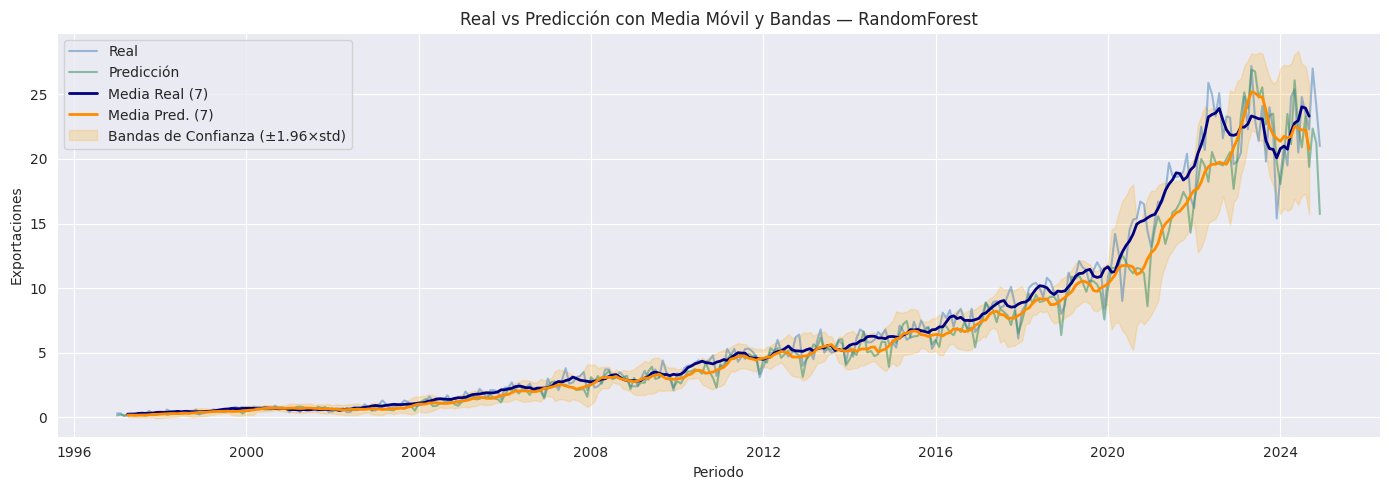

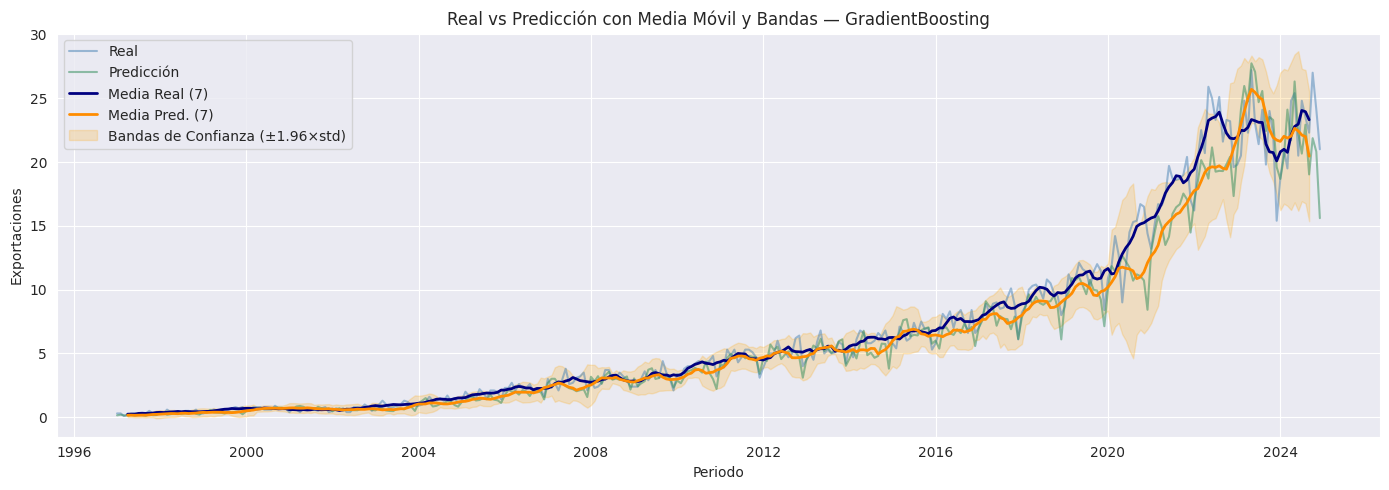

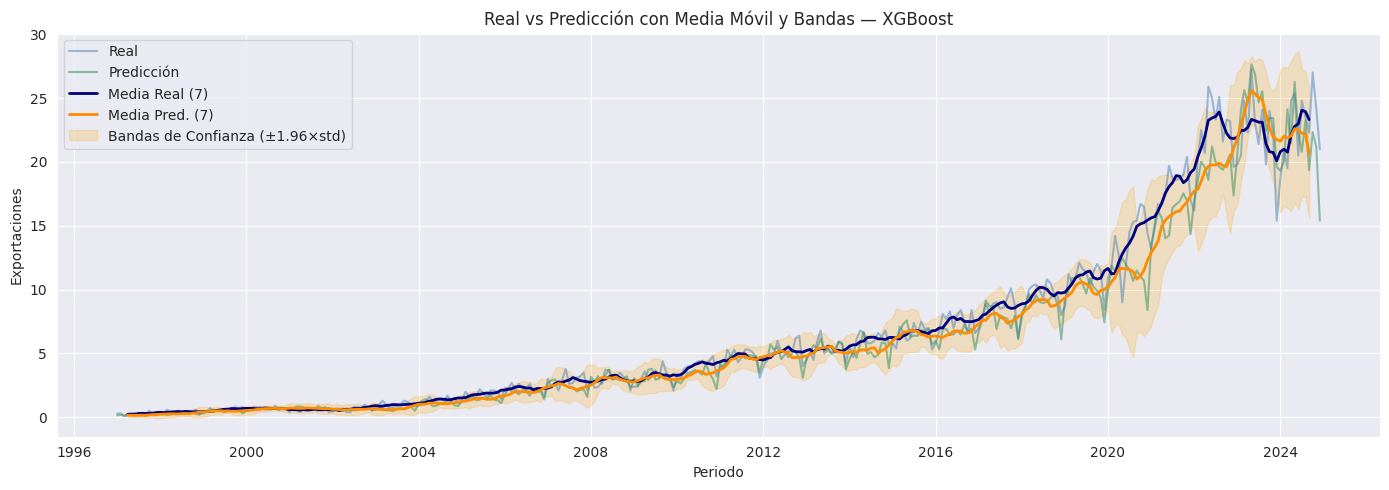

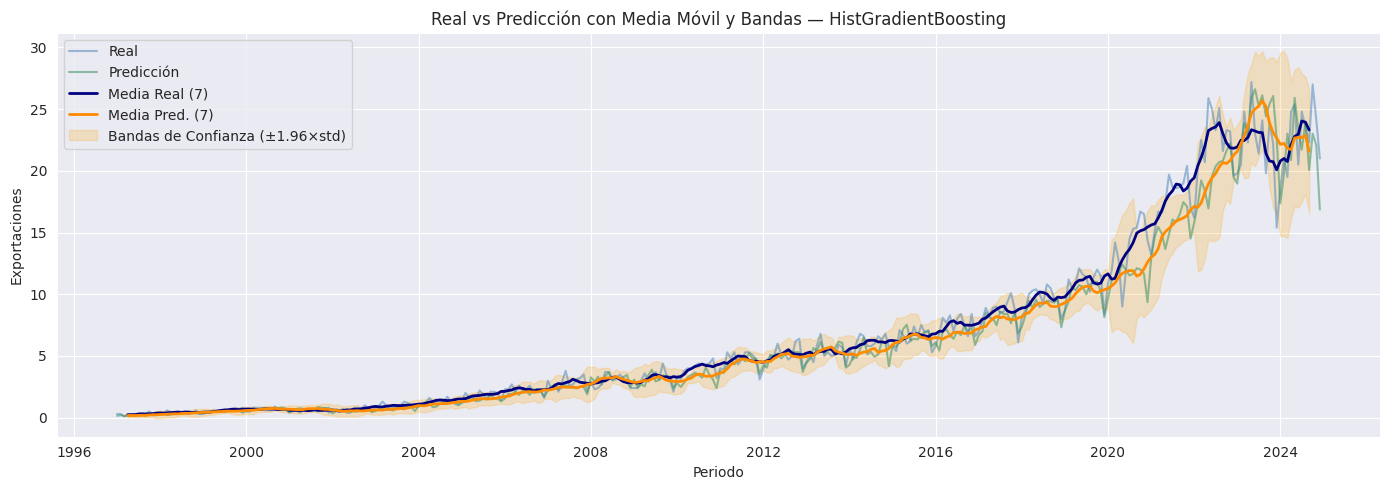

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Ruta base
base = Path("/content/drive/MyDrive/ModeloPronosticos/data")
out = base / "resultados"

# Modelos a procesar
modelos = ["RandomForest", "GradientBoosting", "XGBoost", "HistGradientBoosting"]
ventana = 7

for modelo in modelos:
    path_csv = out / f"predicciones_{modelo}.csv"
    if not path_csv.exists():
        print(f"[Aviso] Archivo no encontrado: {path_csv.name}")
        continue

    # Cargar datos
    df = pd.read_csv(path_csv)
    df["Periodo"] = pd.to_datetime(df["Periodo"])

    # Media móvil y error
    df["Real_smooth"] = df["Real"].rolling(window=ventana, center=True).mean()
    df["Pred_smooth"] = df["Predicho"].rolling(window=ventana, center=True).mean()
    df["Error"] = df["Real"] - df["Predicho"]
    error_std = df["Error"].rolling(window=ventana, center=True).std()
    df["Upper"] = df["Pred_smooth"] + 1.96 * error_std
    df["Lower"] = df["Pred_smooth"] - 1.96 * error_std

    # Gráfica
    plt.figure(figsize=(14, 5))
    plt.plot(df["Periodo"], df["Real"], label="Real", alpha=0.5, color="steelblue")
    plt.plot(df["Periodo"], df["Predicho"], label="Predicción", alpha=0.5, color="seagreen")
    plt.plot(df["Periodo"], df["Real_smooth"], label="Media Real (7)", color="navy", linewidth=2)
    plt.plot(df["Periodo"], df["Pred_smooth"], label="Media Pred. (7)", color="darkorange", linewidth=2)
    plt.fill_between(df["Periodo"], df["Lower"], df["Upper"], alpha=0.2,
                     color="orange", label="Bandas de Confianza (±1.96×std)")
    plt.title(f"Real vs Predicción con Media Móvil y Bandas — {modelo}")
    plt.xlabel("Periodo")
    plt.ylabel("Exportaciones")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out / f"grafico_predicciones_{modelo}.png")
    plt.show()


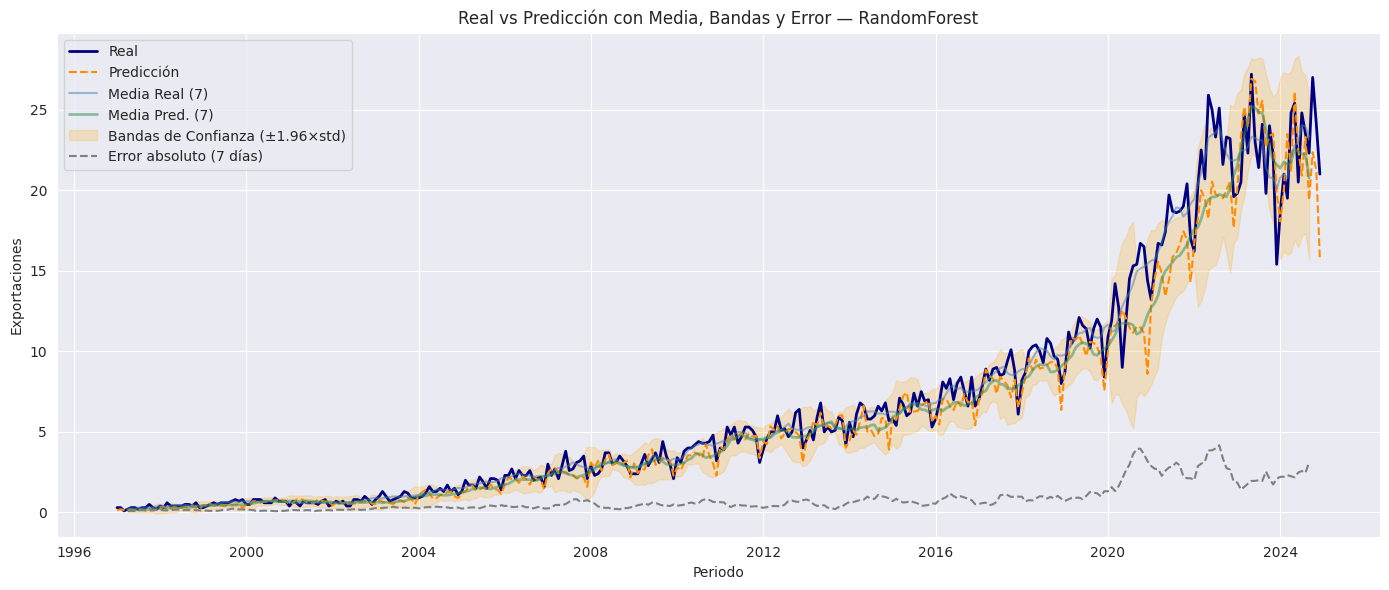

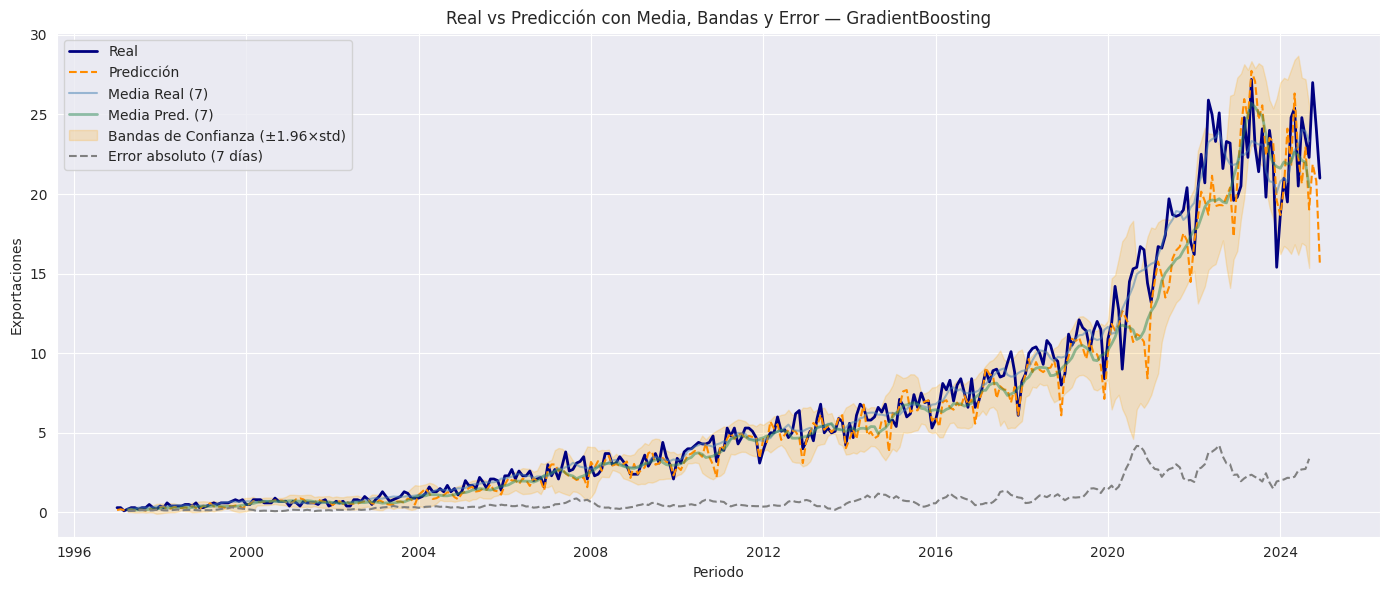

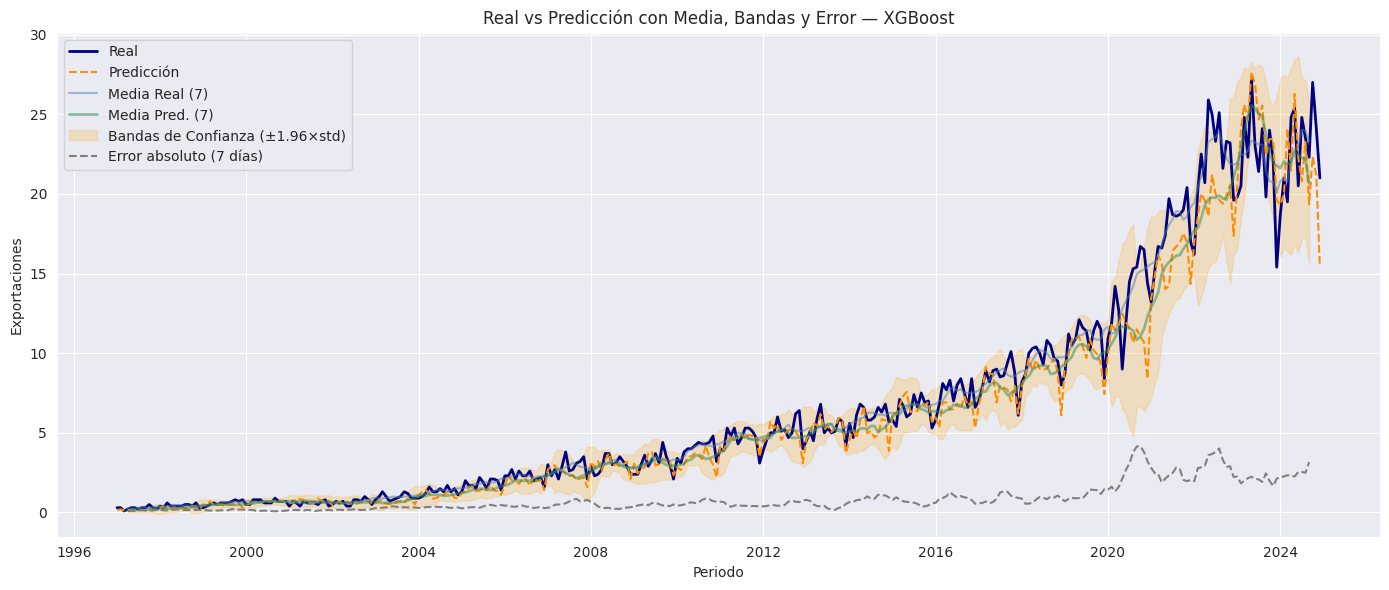

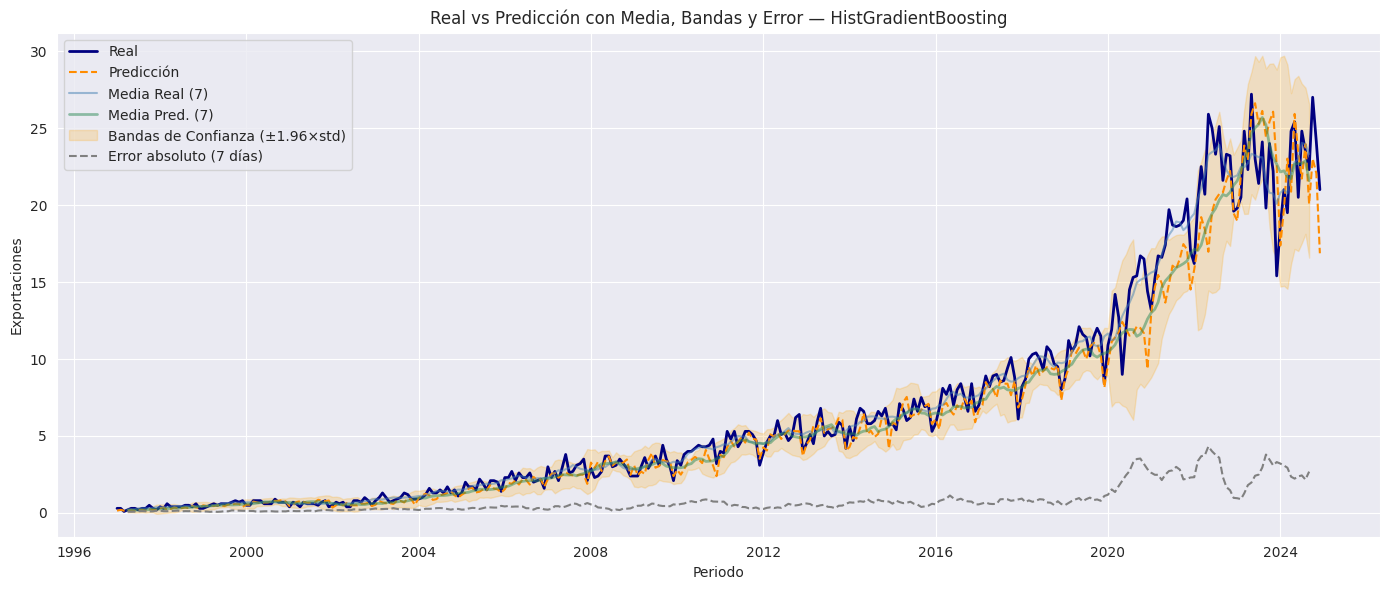

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Rutas
base = Path("/content/drive/MyDrive/ModeloPronosticos/data")
out = base / "resultados"

# Modelos
modelos = ["RandomForest", "GradientBoosting", "XGBoost", "HistGradientBoosting"]
ventana = 7

for modelo in modelos:
    file_path = out / f"predicciones_{modelo}.csv"
    if not file_path.exists():
        print(f"[Aviso] No encontrado: {file_path.name}")
        continue

    # Cargar
    df = pd.read_csv(file_path)
    df["Periodo"] = pd.to_datetime(df["Periodo"])

    # Media móvil y errores
    df["Real_smooth"] = df["Real"].rolling(window=ventana, center=True).mean()
    df["Pred_smooth"] = df["Predicho"].rolling(window=ventana, center=True).mean()
    df["Error"] = df["Real"] - df["Predicho"]
    df["Error_abs"] = df["Error"].abs()
    df["Error_abs_smooth"] = df["Error_abs"].rolling(window=ventana, center=True).mean()
    error_std = df["Error"].rolling(window=ventana, center=True).std()
    df["Upper"] = df["Pred_smooth"] + 1.96 * error_std
    df["Lower"] = df["Pred_smooth"] - 1.96 * error_std

    # Gráfico
    plt.figure(figsize=(14, 6))
    plt.plot(df["Periodo"], df["Real"], alpha=1, label="Real", color="navy", linewidth=2)
    plt.plot(df["Periodo"], df["Predicho"], alpha=1, label="Predicción", color="darkorange",linestyle="--", linewidth=1.5)
    plt.plot(df["Periodo"], df["Real_smooth"], alpha=0.5, label="Media Real (7)", color="steelblue")
    plt.plot(df["Periodo"], df["Pred_smooth"], alpha=0.5, label="Media Pred. (7)", color="seagreen", linewidth=2)
    plt.fill_between(df["Periodo"], df["Lower"], df["Upper"], color="orange", alpha=0.2,
                     label="Bandas de Confianza (±1.96×std)")
    plt.plot(df["Periodo"], df["Error_abs_smooth"], label="Error absoluto (7 días)", color="gray", linestyle="--", linewidth=1.5)

    # Estética
    plt.title(f"Real vs Predicción con Media, Bandas y Error — {modelo}")
    plt.xlabel("Periodo")
    plt.ylabel("Exportaciones")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Guardar
    plt.savefig(out / f"grafico_completo_{modelo}.png", dpi=300)
    plt.show()


# 2. Segunda Aproximación

In [11]:
# ━━━━━━━━━━━━ CARGA DE ARCHIVO ━━━━━━━━━━━━
file_path = "/content/drive/MyDrive/ProyectoIntegrador/ModeloPronosticos/data/consolidado_exportacionestotalcategoria.csv"
df = pd.read_csv(file_path)

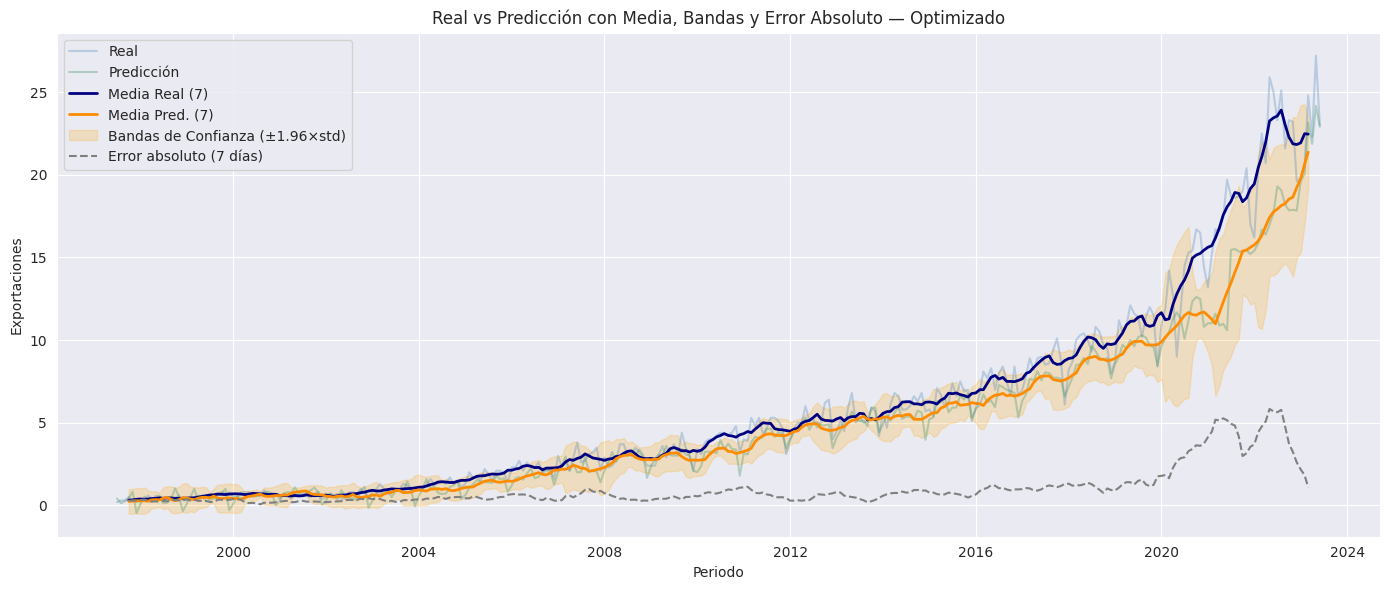

Exportación completada.


In [12]:
# ━━━━━━━━━━━━ LIBRERÍAS ━━━━━━━━━━━━
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
import os
from google.colab import drive
from pathlib import Path

# ━━━━━━━━━━━━ MONTAR Y CARGAR DATOS ━━━━━━━━━━━━


df = df[df["SubCategoria"] == "Tequila 100%"].copy()
df.reset_index(drop=True, inplace=True)
df["Periodo"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Mes"].astype(str).str.zfill(2))
df = df.sort_values("Periodo").set_index("Periodo")

# ━━━━━━━━━━━━ DESCOMPOSICIÓN ━━━━━━━━━━━━
res = seasonal_decompose(df["Valor"], model='additive', period=12)
df_comp = pd.DataFrame({
    "Tendencia": res.trend,
    "Estacionalidad": res.seasonal,
    "Residuo": res.resid
}, index=df.index).dropna().reset_index()

# ━━━━━━━━━━━━ INGENIERÍA BASE ━━━━━━━━━━━━
df_comp["Mes"] = df_comp["Periodo"].dt.month
df_comp["Año"] = df_comp["Periodo"].dt.year
df_comp["Mes_seno"] = np.sin(2 * np.pi * df_comp["Mes"] / 12)
df_comp["Mes_coseno"] = np.cos(2 * np.pi * df_comp["Mes"] / 12)

# ━━━━━━━━━━━━ PARÁMETROS DE BÚSQUEDA ━━━━━━━━━━━━
param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "min_samples_leaf": [5, 10]
}

# ━━━━━━━━━━━━ WALK FORWARD VALIDATION ━━━━━━━━━━━━
window = 12
metricas_modelos = []
predicciones_modelos = []

for start in range(24, len(df_comp) - 2 * window + 1, window):
    end_train = start + window
    end_test = end_train + window

    bloque = df_comp.iloc[start - 24:end_test].copy()
    bloque["Lag1"] = bloque["Residuo"].shift(1)
    bloque["Lag12"] = bloque["Residuo"].shift(12)
    bloque = bloque.dropna().reset_index(drop=True)

    if len(bloque) < (window * 2):
        print(f"[Bloque omitido] No hay suficientes datos después de dropna() en índice {start}")
        continue

    train = bloque.iloc[:window]
    test = bloque.iloc[window:window * 2]

    X_train = train[["Mes", "Año", "Mes_seno", "Mes_coseno", "Lag1", "Lag12"]]
    y_trend = train["Tendencia"]
    y_resid = train["Residuo"]

    X_test = test[["Mes", "Año", "Mes_seno", "Mes_coseno", "Lag1", "Lag12"]]
    y_real = test["Tendencia"] + test["Estacionalidad"] + test["Residuo"]
    tendencia = test["Tendencia"].values
    estacionalidad = test["Estacionalidad"].values

    if X_train.empty or X_test.empty:
        print(f"[Bloque omitido] Train/Test vacío en índice {start}")
        continue

    # Optimización y entrenamiento de modelos separados
    base_model = HistGradientBoostingRegressor(random_state=0)

    trend_model = GridSearchCV(base_model, param_grid, cv=3)
    resid_model = GridSearchCV(base_model, param_grid, cv=3)

    trend_model.fit(X_train, y_trend)
    resid_model.fit(X_train, y_resid)

    trend_pred = trend_model.predict(X_test)
    resid_pred = resid_model.predict(X_test)
    y_pred = trend_pred + estacionalidad + resid_pred

    metricas_modelos.append({
        "Bloque_inicio": test["Periodo"].min(),
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R2": r2_score(y_real, y_pred)
    })

    df_pred = pd.DataFrame({
        "Periodo": test["Periodo"].values,
        "Real": y_real,
        "Predicho": y_pred
    })
    predicciones_modelos.append(df_pred)

# ━━━━━━━━━━━━ EXPORTAR ━━━━━━━━━━━━
out = Path("/content/drive/MyDrive/ModeloPronosticos/data/resultados")
out.mkdir(parents=True, exist_ok=True)

# Exportar métricas
pd.DataFrame(metricas_modelos).to_csv(out / "metricas_optimizadas.csv", index=False)

# Exportar predicciones solo si hay datos
if predicciones_modelos:
    df_preds = pd.concat(predicciones_modelos).reset_index(drop=True)
    df_preds.to_csv(out / "predicciones_optimizadas.csv", index=False)

    # ━━━━━━━━━━━━ GRÁFICO CON BANDAS Y ERROR ABSOLUTO ━━━━━━━━━━━━
    df_preds["Periodo"] = pd.to_datetime(df_preds["Periodo"])
    ventana = 7
    df_preds["Real_smooth"] = df_preds["Real"].rolling(window=ventana, center=True).mean()
    df_preds["Pred_smooth"] = df_preds["Predicho"].rolling(window=ventana, center=True).mean()
    df_preds["Error"] = df_preds["Real"] - df_preds["Predicho"]
    df_preds["Error_abs"] = df_preds["Error"].abs()
    df_preds["Error_abs_smooth"] = df_preds["Error_abs"].rolling(window=ventana, center=True).mean()
    error_std = df_preds["Error"].rolling(window=ventana, center=True).std()
    df_preds["Upper"] = df_preds["Pred_smooth"] + 1.96 * error_std
    df_preds["Lower"] = df_preds["Pred_smooth"] - 1.96 * error_std

    plt.figure(figsize=(14, 6))
    plt.plot(df_preds["Periodo"], df_preds["Real"], alpha=0.3, label="Real", color="steelblue")
    plt.plot(df_preds["Periodo"], df_preds["Predicho"], alpha=0.3, label="Predicción", color="seagreen")
    plt.plot(df_preds["Periodo"], df_preds["Real_smooth"], label="Media Real (7)", color="navy", linewidth=2)
    plt.plot(df_preds["Periodo"], df_preds["Pred_smooth"], label="Media Pred. (7)", color="darkorange", linewidth=2)
    plt.fill_between(df_preds["Periodo"], df_preds["Lower"], df_preds["Upper"], color="orange", alpha=0.2,
                     label="Bandas de Confianza (±1.96×std)")
    plt.plot(df_preds["Periodo"], df_preds["Error_abs_smooth"], label="Error absoluto (7 días)",
             color="gray", linestyle="--", linewidth=1.5)

    plt.title("Real vs Predicción con Media, Bandas y Error Absoluto — Optimizado")
    plt.xlabel("Periodo")
    plt.ylabel("Exportaciones")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out / "grafico_predicciones_optimizadas.png", dpi=300)
    plt.show()

else:
    print("[Advertencia] No se generaron predicciones válidas. No se exportó el archivo.")

print("Exportación completada.")


RED NEURONAL

In [13]:
# ━━━━━━━━━━━━ CARGA DE ARCHIVO ━━━━━━━━━━━━
file_path = "/content/drive/MyDrive/ProyectoIntegrador/ModeloPronosticos/data/consolidado_exportacionestotalcategoria.csv"
df = pd.read_csv(file_path)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss
  current = self.get_monitor_value(logs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


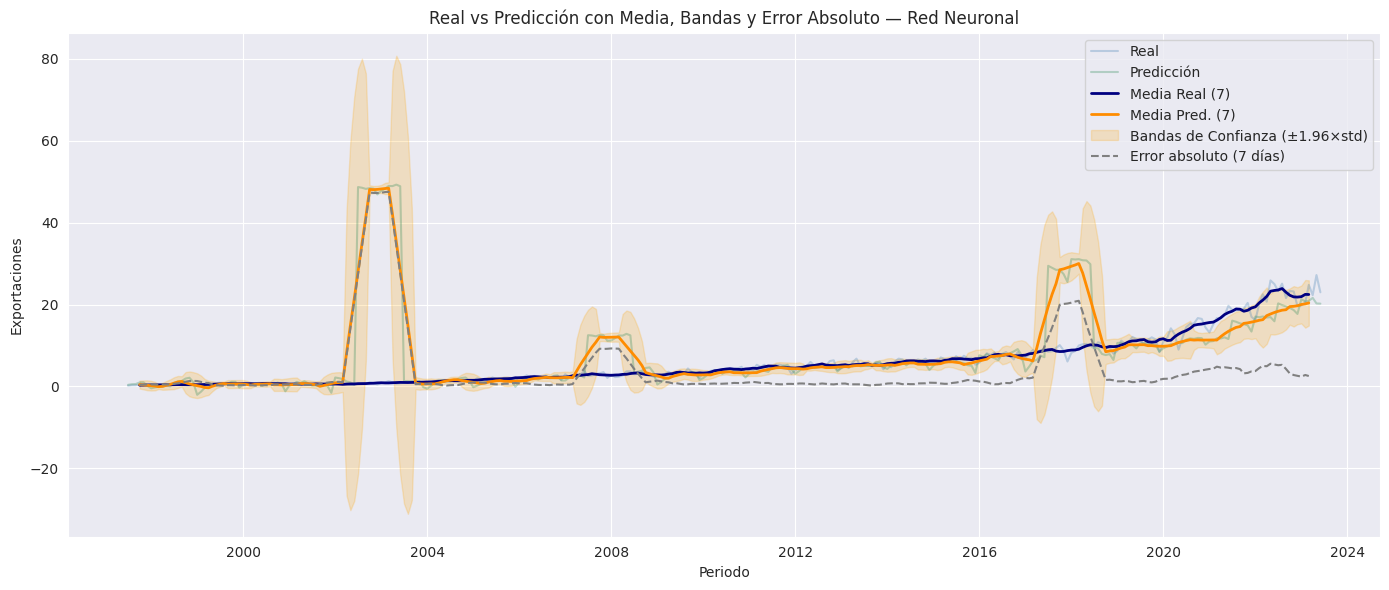

Exportación completada.


In [14]:
df = pd.read_csv(file_path)
# ━━━━━━━━━━━━ MONTAR Y CARGAR DATOS ━━━━━━━━━━━━
df = pd.read_csv(file_path)
df = df[df["SubCategoria"] == "Tequila 100%"].copy()
df.reset_index(drop=True, inplace=True)
df["Periodo"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Mes"].astype(str).str.zfill(2))
df = df.sort_values("Periodo").set_index("Periodo")

# ━━━━━━━━━━━━ DESCOMPOSICIÓN ━━━━━━━━━━━━
res = seasonal_decompose(df["Valor"], model='additive', period=12)
df_comp = pd.DataFrame({
    "Tendencia": res.trend,
    "Estacionalidad": res.seasonal,
    "Residuo": res.resid
}, index=df.index).dropna().reset_index()

# ━━━━━━━━━━━━ INGENIERÍA BASE ━━━━━━━━━━━━
df_comp["Mes"] = df_comp["Periodo"].dt.month
df_comp["Año"] = df_comp["Periodo"].dt.year
df_comp["Mes_seno"] = np.sin(2 * np.pi * df_comp["Mes"] / 12)
df_comp["Mes_coseno"] = np.cos(2 * np.pi * df_comp["Mes"] / 12)

# ━━━━━━━━━━━━ WALK FORWARD VALIDATION ━━━━━━━━━━━━
window = 12
metricas_modelos = []
predicciones_modelos = []

for start in range(24, len(df_comp) - 2 * window + 1, window):
    end_train = start + window
    end_test = end_train + window

    bloque = df_comp.iloc[start - 24:end_test].copy()
    bloque["Lag1"] = bloque["Residuo"].shift(1)
    bloque["Lag12"] = bloque["Residuo"].shift(12)
    bloque = bloque.dropna().reset_index(drop=True)

    if len(bloque) < (window * 2):
        print(f"[Bloque omitido] No hay suficientes datos después de dropna() en índice {start}")
        continue

    train = bloque.iloc[:window]
    test = bloque.iloc[window:window * 2]

    X_train = train[["Mes", "Año", "Mes_seno", "Mes_coseno", "Lag1", "Lag12"]].values
    y_trend = train["Tendencia"].values
    y_resid = train["Residuo"].values

    X_test = test[["Mes", "Año", "Mes_seno", "Mes_coseno", "Lag1", "Lag12"]].values
    y_real = test["Tendencia"] + test["Estacionalidad"] + test["Residuo"]
    tendencia = test["Tendencia"].values
    estacionalidad = test["Estacionalidad"].values

    if X_train.size == 0 or X_test.size == 0:
        print(f"[Bloque omitido] Train/Test vacío en índice {start}")
        continue

    def build_model():
        model = Sequential([
            Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
            Dense(16, activation='relu'),
            Dense(1)
        ])
        model.compile(optimizer='adam', loss='mse')
        return model

    es = EarlyStopping(patience=10, restore_best_weights=True)

    # Modelo de tendencia
    trend_model = build_model()
    trend_model.fit(X_train, y_trend, epochs=100, batch_size=8, verbose=0, callbacks=[es])
    trend_pred = trend_model.predict(X_test).flatten()

    # Modelo de residuo
    resid_model = build_model()
    resid_model.fit(X_train, y_resid, epochs=100, batch_size=8, verbose=0, callbacks=[es])
    resid_pred = resid_model.predict(X_test).flatten()

    y_pred = trend_pred + estacionalidad + resid_pred

    metricas_modelos.append({
        "Bloque_inicio": test["Periodo"].min(),
        "MAE": mean_absolute_error(y_real, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_real, y_pred)),
        "R2": r2_score(y_real, y_pred)
    })

    df_pred = pd.DataFrame({
        "Periodo": test["Periodo"].values,
        "Real": y_real,
        "Predicho": y_pred
    })
    predicciones_modelos.append(df_pred)

# ━━━━━━━━━━━━ EXPORTAR ━━━━━━━━━━━━
out = Path("/content/drive/MyDrive/ModeloPronosticos/data/resultados")
out.mkdir(parents=True, exist_ok=True)

# Exportar métricas
pd.DataFrame(metricas_modelos).to_csv(out / "metricas_nn.csv", index=False)

# Exportar predicciones solo si hay datos
if predicciones_modelos:
    df_preds = pd.concat(predicciones_modelos).reset_index(drop=True)
    df_preds.to_csv(out / "predicciones_nn.csv", index=False)

    # ━━━━━━━━━━━━ GRÁFICO CON BANDAS Y ERROR ABSOLUTO ━━━━━━━━━━━━
    df_preds["Periodo"] = pd.to_datetime(df_preds["Periodo"])
    ventana = 7
    df_preds["Real_smooth"] = df_preds["Real"].rolling(window=ventana, center=True).mean()
    df_preds["Pred_smooth"] = df_preds["Predicho"].rolling(window=ventana, center=True).mean()
    df_preds["Error"] = df_preds["Real"] - df_preds["Predicho"]
    df_preds["Error_abs"] = df_preds["Error"].abs()
    df_preds["Error_abs_smooth"] = df_preds["Error_abs"].rolling(window=ventana, center=True).mean()
    error_std = df_preds["Error"].rolling(window=ventana, center=True).std()
    df_preds["Upper"] = df_preds["Pred_smooth"] + 1.96 * error_std
    df_preds["Lower"] = df_preds["Pred_smooth"] - 1.96 * error_std

    plt.figure(figsize=(14, 6))
    plt.plot(df_preds["Periodo"], df_preds["Real"], alpha=0.3, label="Real", color="steelblue")
    plt.plot(df_preds["Periodo"], df_preds["Predicho"], alpha=0.3, label="Predicción", color="seagreen")
    plt.plot(df_preds["Periodo"], df_preds["Real_smooth"], label="Media Real (7)", color="navy", linewidth=2)
    plt.plot(df_preds["Periodo"], df_preds["Pred_smooth"], label="Media Pred. (7)", color="darkorange", linewidth=2)
    plt.fill_between(df_preds["Periodo"], df_preds["Lower"], df_preds["Upper"], color="orange", alpha=0.2,
                     label="Bandas de Confianza (±1.96×std)")
    plt.plot(df_preds["Periodo"], df_preds["Error_abs_smooth"], label="Error absoluto (7 días)",
             color="gray", linestyle="--", linewidth=1.5)

    plt.title("Real vs Predicción con Media, Bandas y Error Absoluto — Red Neuronal")
    plt.xlabel("Periodo")
    plt.ylabel("Exportaciones")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out / "grafico_predicciones_nn.png", dpi=300)
    plt.show()

else:
    print("[Advertencia] No se generaron predicciones válidas. No se exportó el archivo.")

print("Exportación completada.")


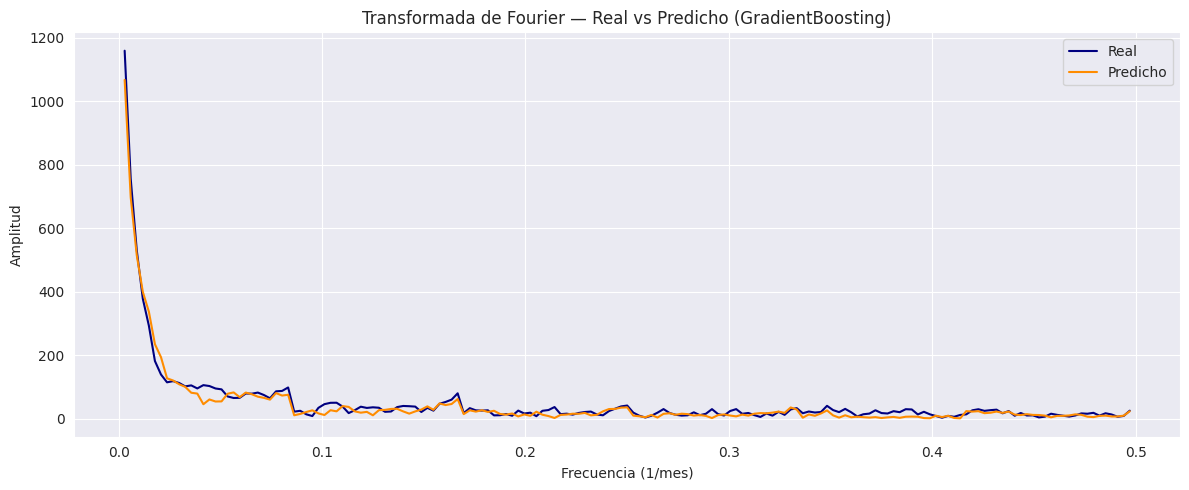

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ━━━━━━━━━━━━ CARGA DE DATOS ━━━━━━━━━━━━
base = Path("/content/drive/MyDrive/ModeloPronosticos/data/resultados")
df = pd.read_csv(base / "predicciones_GradientBoosting.csv")
df["Periodo"] = pd.to_datetime(df["Periodo"])
df = df.sort_values("Periodo")

# ━━━━━━━━━━━━ TRANSFORMADA DE FOURIER ━━━━━━━━━━━━
def plot_fft(serie, label, color):
    n = len(serie)
    fft_vals = np.fft.fft(serie - np.mean(serie))  # quitar componente DC
    freqs = np.fft.fftfreq(n)

    # Usar solo mitad positiva (simétrica)
    idx = freqs > 0
    freqs = freqs[idx]
    amplitudes = np.abs(fft_vals[idx])

    plt.plot(freqs, amplitudes, label=label, color=color)

# ━━━━━━━━━━━━ GRAFICAR FFT ━━━━━━━━━━━━
plt.figure(figsize=(12, 5))
plot_fft(df["Real"].values, "Real", "navy")
plot_fft(df["Predicho"].values, "Predicho", "darkorange")

plt.title("Transformada de Fourier — Real vs Predicho (GradientBoosting)")
plt.xlabel("Frecuencia (1/mes)")
plt.ylabel("Amplitud")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


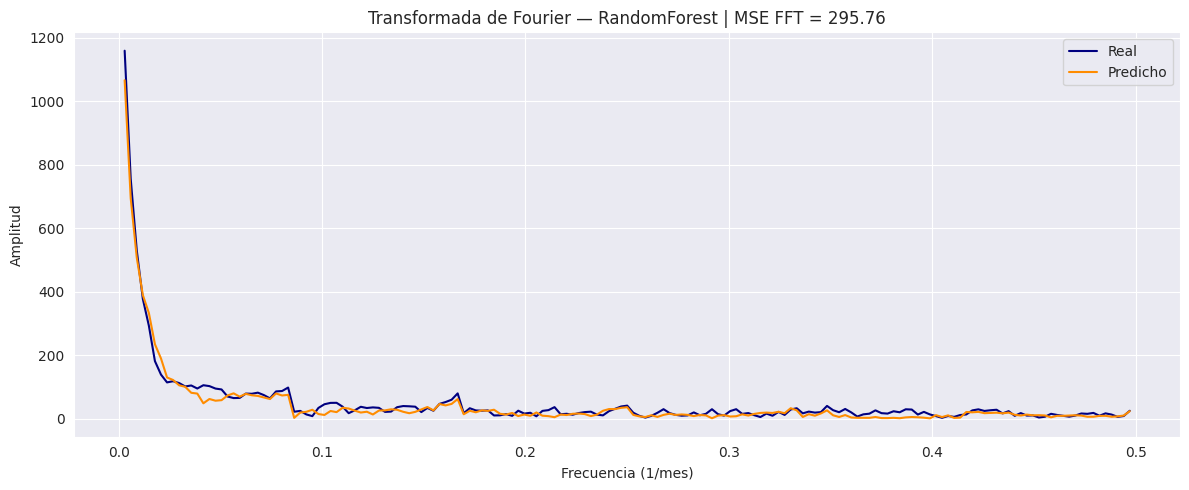

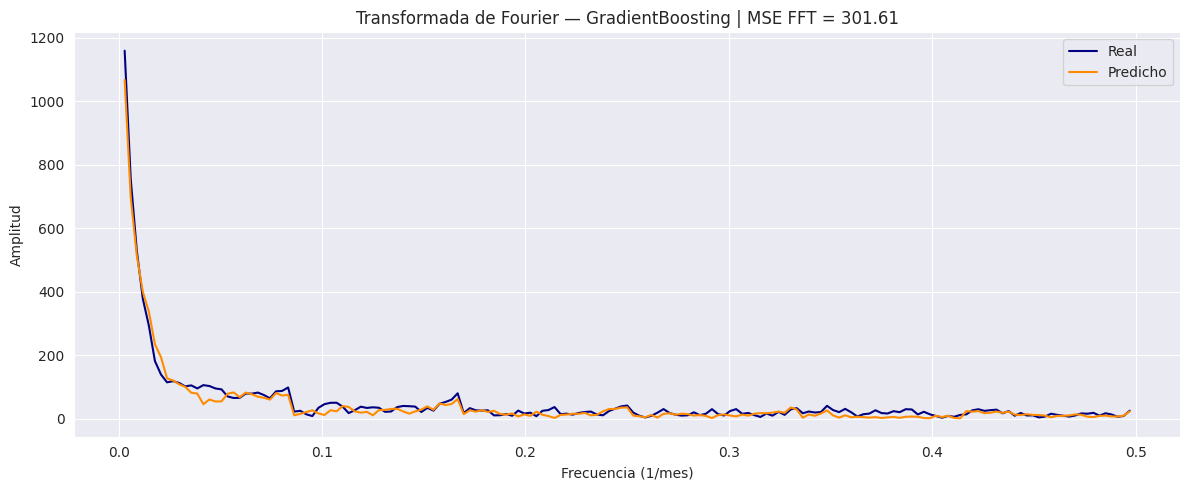

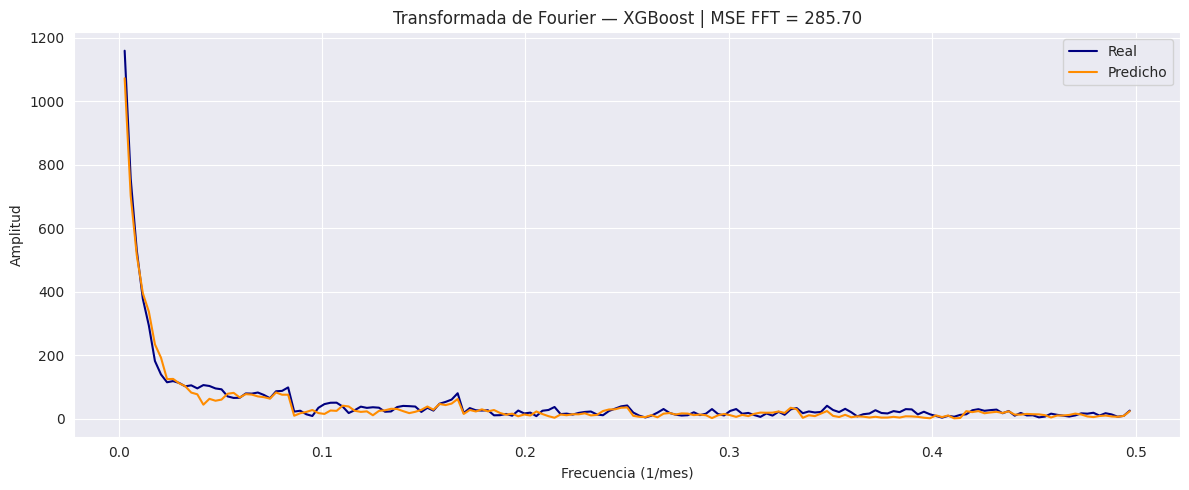

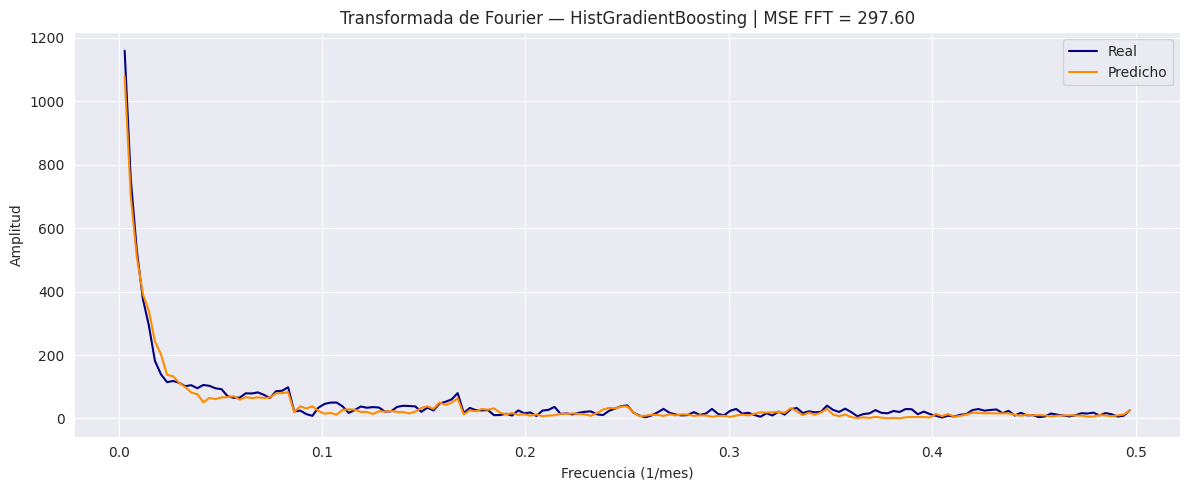

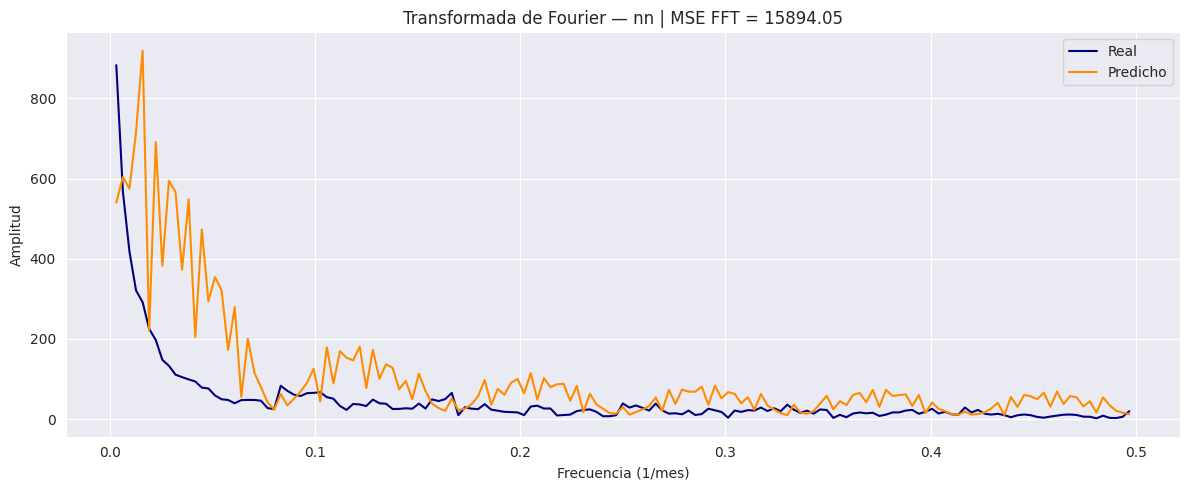

[Aviso] No se encontró: predicciones_lstm.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from pathlib import Path

# Ruta base
base = Path("/content/drive/MyDrive/ModeloPronosticos/data/resultados")
modelos = ["RandomForest", "GradientBoosting", "XGBoost", "HistGradientBoosting", "nn", "lstm"]

def plot_fft_mse(df, modelo):
    real = df["Real"].values - np.mean(df["Real"].values)
    pred = df["Predicho"].values - np.mean(df["Predicho"].values)
    n = len(real)

    # FFT y frecuencias (quitando frecuencia 0)
    fft_real = np.abs(np.fft.fft(real))[1:n//2]
    fft_pred = np.abs(np.fft.fft(pred))[1:n//2]
    freqs = np.fft.fftfreq(n)[1:n//2]

    # MSE espectral
    mse_fft = mean_squared_error(fft_real, fft_pred)

    # Gráfico
    plt.figure(figsize=(12, 5))
    plt.plot(freqs, fft_real, label="Real", color="navy")
    plt.plot(freqs, fft_pred, label="Predicho", color="darkorange")
    plt.title(f"Transformada de Fourier — {modelo} | MSE FFT = {mse_fft:.2f}")
    plt.xlabel("Frecuencia (1/mes)")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(base / f"fft_{modelo}_mse.png", dpi=300)
    plt.show()

# Ejecutar para cada modelo
for modelo in modelos:
    file = base / f"predicciones_{modelo}.csv"
    if file.exists():
        df = pd.read_csv(file)
        plot_fft_mse(df, modelo)
    else:
        print(f"[Aviso] No se encontró: {file.name}")
